CREDIT CARD FRAUD DETECTION

Current working directory:
C:\Users\Santanu Mondal\Downloads\files\jupytertest

Loading dataset...

Dataset loaded successfully!

Dataset Shape:
(284807, 31)

First 5 Rows:
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.3

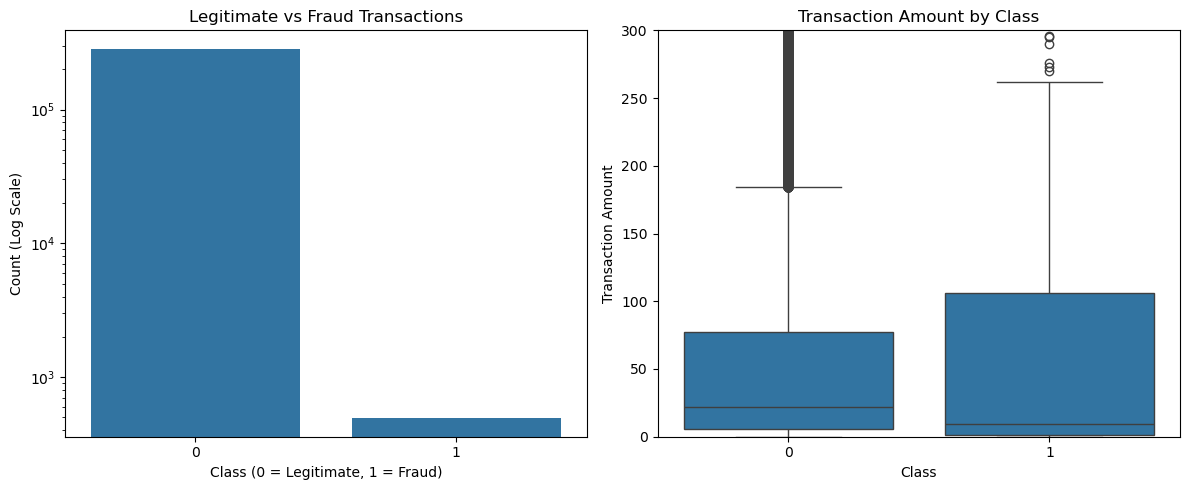

Saved: eda_overview.png

Scaling Time and Amount...
Scaling completed.

Features shape:
(284807, 30)

Target shape:
(284807,)

Splitting dataset...
Training samples: 227845
Testing samples: 56962


MODEL: Logistic Regression

Training model...

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      0.98      0.99     56864
       Fraud       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962

Confusion Matrix:
[[55475  1389]
 [    8    90]]

ROC-AUC Score: 0.9722


MODEL: Decision Tree

Training model...

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      0.98      0.99     56864
       Fraud       0.07      0.83      0.13        98

    accuracy                           0.98     56962
   macro avg       0.53      0.90      0.56     5

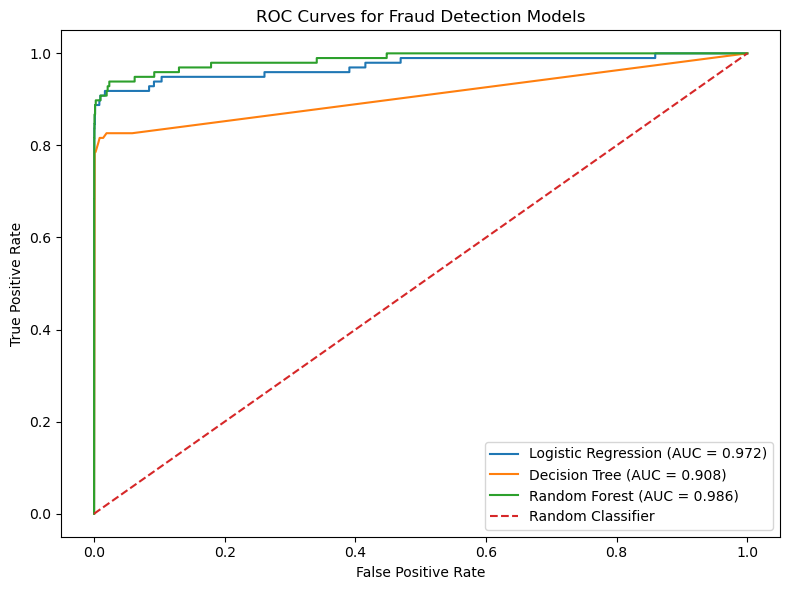


Saved: model_evaluation.png


MODEL PERFORMANCE COMPARISON
Logistic Regression: ROC-AUC = 0.9722
Decision Tree: ROC-AUC = 0.9075
Random Forest: ROC-AUC = 0.9863

Best Model:
Random Forest
Best ROC-AUC Score: 0.9863


PROJECT COMPLETED SUCCESSFULLY!

Generated files:
1. eda_overview.png
2. model_evaluation.png


In [6]:
# ============================================================
# CodSoft ML Internship - Task 2
# Credit Card Fraud Detection
# Author: Santanu Mondal
# ============================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)


# ============================================================
# 1. SETTINGS
# ============================================================

SEED = 42
DATASET_FILE = "creditcard.csv"


# ============================================================
# 2. LOAD DATASET
# ============================================================

print("=" * 60)
print("CREDIT CARD FRAUD DETECTION")
print("=" * 60)

print("\nCurrent working directory:")
print(os.getcwd())

print("\nLoading dataset...")

if not os.path.exists(DATASET_FILE):
    raise FileNotFoundError(
        f"\n'{DATASET_FILE}' was not found.\n"
        f"Place creditcard.csv inside:\n{os.getcwd()}"
    )

df = pd.read_csv(DATASET_FILE)

print("\nDataset loaded successfully!")

print("\nDataset Shape:")
print(df.shape)

print("\nFirst 5 Rows:")
print(df.head())


# ============================================================
# 3. DATASET INFORMATION
# ============================================================

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum().sum())

print("\nClass Distribution:")
print(df["Class"].value_counts())


# ============================================================
# 4. CHECK CLASS IMBALANCE
# ============================================================

fraud_percent = df["Class"].mean() * 100

print(
    f"\nFraud transactions are only "
    f"{fraud_percent:.3f}% of the dataset."
)

print("This is a highly imbalanced classification problem.")


# ============================================================
# 5. EXPLORATORY DATA ANALYSIS
# ============================================================

print("\nCreating EDA plots...")

plt.figure(figsize=(12, 5))


# Class distribution
plt.subplot(1, 2, 1)

sns.countplot(
    x="Class",
    data=df
)

plt.yscale("log")

plt.title("Legitimate vs Fraud Transactions")
plt.xlabel("Class (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Count (Log Scale)")


# Amount distribution
plt.subplot(1, 2, 2)

sns.boxplot(
    x="Class",
    y="Amount",
    data=df
)

plt.ylim(0, 300)

plt.title("Transaction Amount by Class")
plt.xlabel("Class")
plt.ylabel("Transaction Amount")


plt.tight_layout()

plt.savefig(
    "eda_overview.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()

print("Saved: eda_overview.png")


# ============================================================
# 6. SCALE TIME AND AMOUNT
# ============================================================

print("\nScaling Time and Amount...")

scaler = StandardScaler()

df["scaled_amount"] = scaler.fit_transform(
    df["Amount"].values.reshape(-1, 1)
)

df["scaled_time"] = scaler.fit_transform(
    df["Time"].values.reshape(-1, 1)
)


# Remove original columns
df.drop(
    ["Time", "Amount"],
    axis=1,
    inplace=True
)

print("Scaling completed.")


# ============================================================
# 7. PREPARE FEATURES AND TARGET
# ============================================================

X = df.drop(
    "Class",
    axis=1
)

y = df["Class"]

print("\nFeatures shape:")
print(X.shape)

print("\nTarget shape:")
print(y.shape)


# ============================================================
# 8. TRAIN-TEST SPLIT
# ============================================================

print("\nSplitting dataset...")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))


# ============================================================
# 9. DEFINE MACHINE LEARNING MODELS
# ============================================================

models = {

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=SEED
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=8,
        class_weight="balanced",
        random_state=SEED
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=150,
        max_depth=10,
        class_weight="balanced",
        random_state=SEED,
        n_jobs=-1
    )
}


# ============================================================
# 10. TRAIN AND EVALUATE MODELS
# ============================================================

model_results = {}

plt.figure(figsize=(8, 6))

for name, model in models.items():

    print("\n")
    print("=" * 60)
    print("MODEL:", name)
    print("=" * 60)

    # Train
    print("\nTraining model...")

    model.fit(
        X_train,
        y_train
    )

    # Predictions
    predictions = model.predict(
        X_test
    )

    probabilities = model.predict_proba(
        X_test
    )[:, 1]


    # --------------------------------------------------------
    # Classification Report
    # --------------------------------------------------------

    print("\nClassification Report:")

    print(
        classification_report(
            y_test,
            predictions,
            target_names=[
                "Legitimate",
                "Fraud"
            ]
        )
    )


    # --------------------------------------------------------
    # Confusion Matrix
    # --------------------------------------------------------

    print("Confusion Matrix:")

    cm = confusion_matrix(
        y_test,
        predictions
    )

    print(cm)


    # --------------------------------------------------------
    # ROC-AUC
    # --------------------------------------------------------

    auc = roc_auc_score(
        y_test,
        probabilities
    )

    print(
        f"\nROC-AUC Score: {auc:.4f}"
    )

    model_results[name] = auc


    # --------------------------------------------------------
    # ROC Curve
    # --------------------------------------------------------

    fpr, tpr, _ = roc_curve(
        y_test,
        probabilities
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {auc:.3f})"
    )


# ============================================================
# 11. ROC CURVE
# ============================================================

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "ROC Curves for Fraud Detection Models"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    "model_evaluation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()

print("\nSaved: model_evaluation.png")


# ============================================================
# 12. MODEL COMPARISON
# ============================================================

print("\n")
print("=" * 60)
print("MODEL PERFORMANCE COMPARISON")
print("=" * 60)

for name, score in model_results.items():

    print(
        f"{name}: ROC-AUC = {score:.4f}"
    )


# ============================================================
# 13. BEST MODEL
# ============================================================

best_model = max(
    model_results,
    key=model_results.get
)

best_score = model_results[best_model]

print("\nBest Model:")
print(best_model)

print(
    f"Best ROC-AUC Score: {best_score:.4f}"
)


# ============================================================
# 14. COMPLETION MESSAGE
# ============================================================

print("\n")
print("=" * 60)
print("PROJECT COMPLETED SUCCESSFULLY!")
print("=" * 60)

print("\nGenerated files:")
print("1. eda_overview.png")
print("2. model_evaluation.png")